<a href="https://colab.research.google.com/github/Bismarc228/MatStatLab/blob/Lab1/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Статистика для анализа данных
Лабораторная работа 1
Расчет геометрической вероятности


# 1. Основная информация по отчету

## Выполнил - Светлов Ярослав Геннадьевич, 467390, ИИИ 1.1

# 2. Ход выполнения работы

1. Рассчитал истинную геометрическую вероятность как отношение соответствующих площадей.
2. При помощи генератора случайных чисел разместил точки в Ω (пространство элементарных исходов) и определил их принадлежность $𝓐(r)$ (окружность радиуса $r$).
3. Построил график  $\tilde{p}(n)$ , где $\tilde{p}$ - доля точек, которые попали в круг, а $n$ - количество точек.
4. Построил график $ε(n) =  | \tilde{p}(n) - \tilde{p} |$ для анализа  изменения ошибки оценки геометрической вероятности

## Импортируем необходимые библиотеки
При выполнении лабораторной работы были использованы библиотеки: numpy (для быстрых математических вычислений) и matplotlib (для визуализации полученных данных)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

##Необходимые константы
В дальнейшем требуются некоторые константы, в нашем случае количество радиусов (num_rad) для наших окружностей, а также скаляр $a$, который необходим для правильного расставления границ промежутков и длинны сторон квадрата (сторона квадрта задается как $2a$). num_point - количество точек

In [ ]:
a = 100
num_point = 500
num_rad = 5

##Задание последовательности радиусов
Наша последовательность радиусов окружностей (num_rad штук) задается по формуле $r_i = a / (i + 1)$

In [ ]:
rad = [a / (i + 1) for i in range(num_rad)]

## Расщет площадей окружностей и квалрата и истенных геометрических вероятностей
$S_i = \pi \cdot \text{rad}_i^2$ - окружности

$S_\square = (2a)^2$ - квадрат

$p_i = S_i / S_\square$

In [ ]:
arena_squares = (2 * a) ** 2
arena_circles = [np.pi * (r ** 2) for r in rad]
true_geometric_probability = [area / arena_squares for area in arena_circles]

##Применение метода Монте-Карло

In [ ]:
points = np.random.uniform(0, 2 * a, (num_point, 2))
points_in_circles = [np.empty((0, 2)) for _ in range(num_rad)]

for point in points:
    x, y = point
    for i, r in enumerate(rad):
        if (x - a) ** 2 + (y - a) ** 2 < r ** 2:
            points_in_circles[i] = np.vstack([points_in_circles[i], point])

In [ ]:
aw = [[] for _ in range(num_rad)]

for j in range(num_rad):
    n = 0
    rn = 0
    for i in range(num_point):
        n += 1
        x, y = np.random.random(2) * a
        if (x - a) ** 2 + (y - a) ** 2 < rad[j] ** 2:
            rn += 1
        aw[j].append((n, rn / n))
aw = np.array(aw)

##Визуализация метода

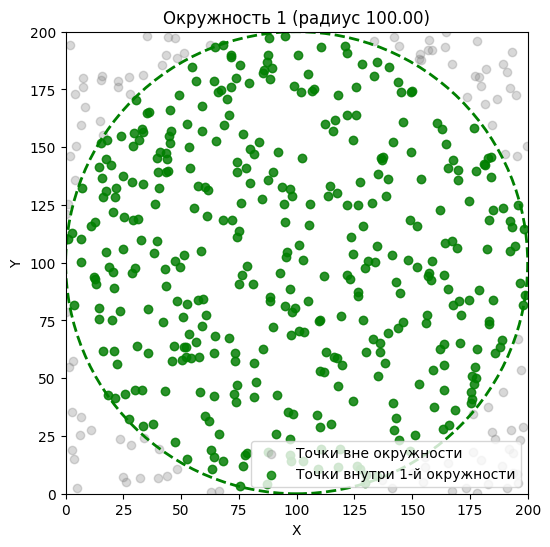

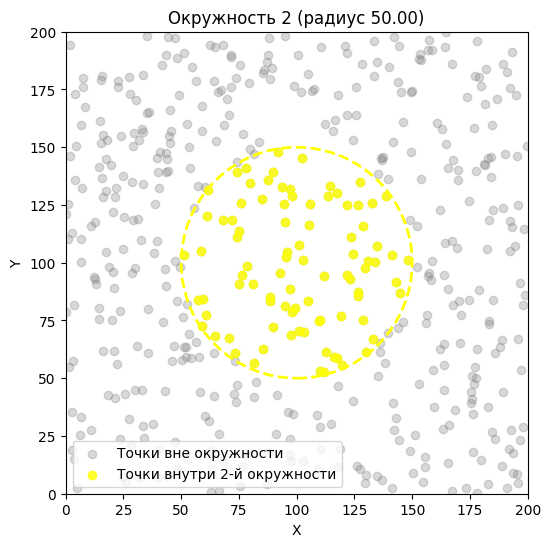

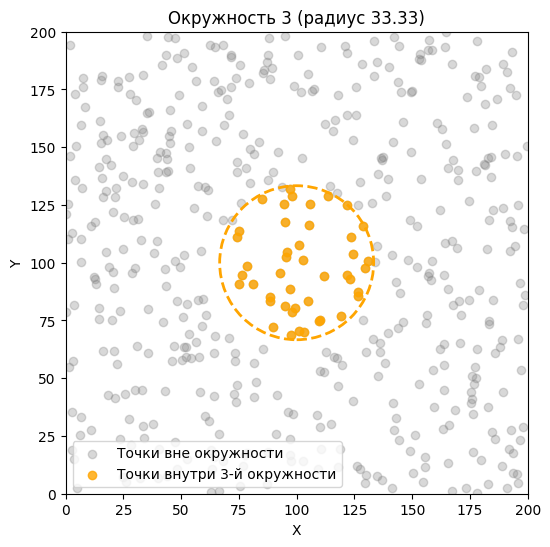

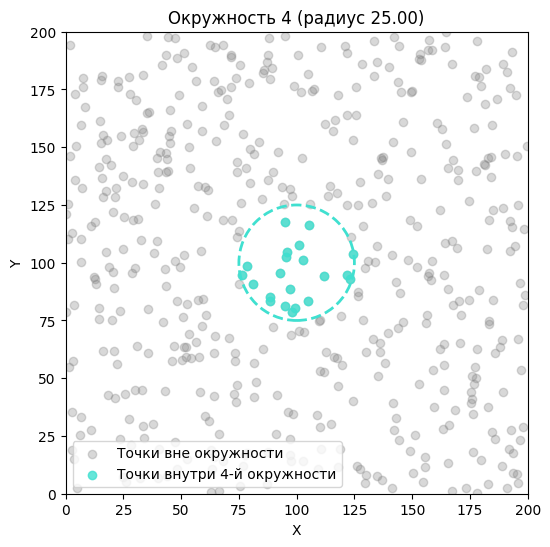

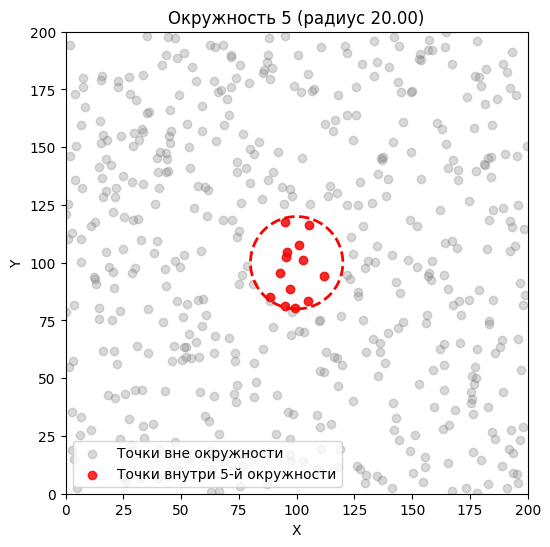

In [ ]:
point_colors = np.array(['gray'] * num_point)
colors = ['Green','Yellow','Orange','Turquoise','Red','Purple','Cyan','Pink','LightYellow','Magenta']

for i in range(num_rad):
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(points[:, 0], points[:, 1], color='gray', alpha=0.3, label='Точки вне окружности')

    points_array = np.array(points_in_circles[i])
    ax.scatter(points_array[:, 0], points_array[:, 1],
                   color=colors[i], alpha=0.8, label=f'Точки внутри {i+1}-й окружности')


    circle = plt.Circle((a, a), rad[i], color=colors[i], fill=False, linestyle='dashed', linewidth=2)
    ax.add_patch(circle)


    ax.set_xlim(0, 2 * a)
    ax.set_ylim(0, 2 * a)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Окружность {i+1} (радиус {rad[i]:.2f})')
    ax.legend()
    ax.set_aspect('equal')

    plt.show()

##Построим график $\tilde{p}(n)$ , где $\tilde{p}$  — доля точек, которые попали в круг, а $n$ — количество точек
Выбирая значения мы сможем показать, что чем больше у нас точек, тем точней метод Монте-Карло показывает вероятность $ ⇒ $ при $ n \to ∞ $ мы практически получаем нашу истинную геометрическую вероятность
Другими словами, $\lim\limits_{x \to ∞}\tilde{p}(n) = {p} $

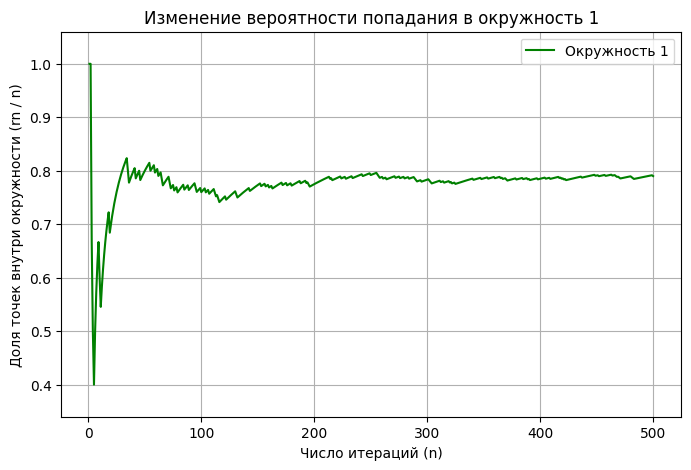

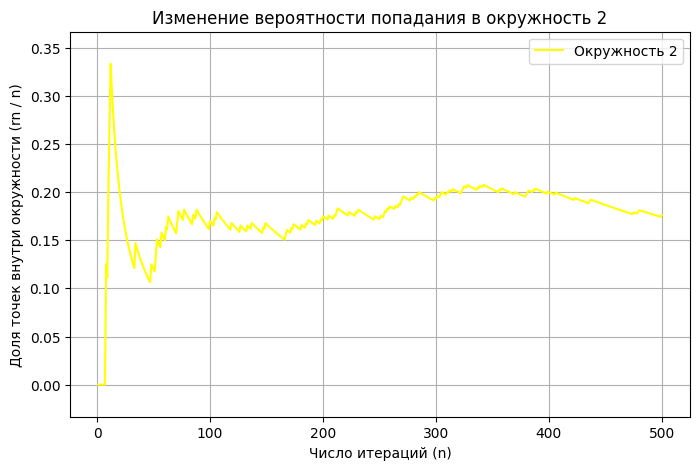

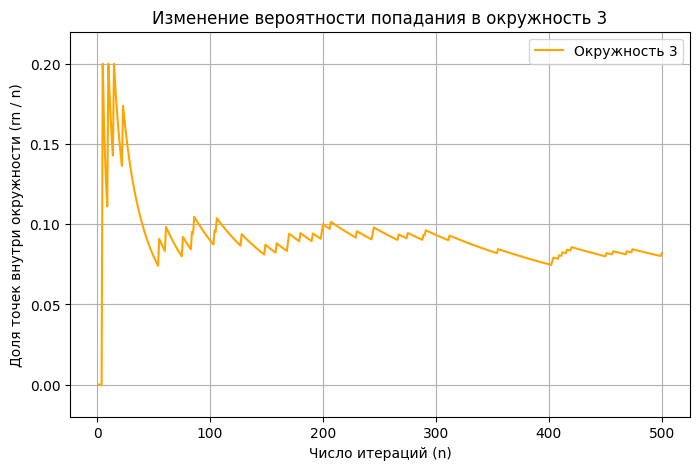

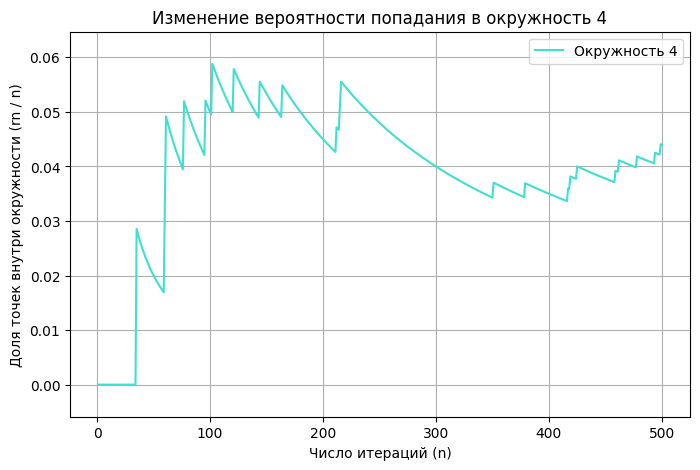

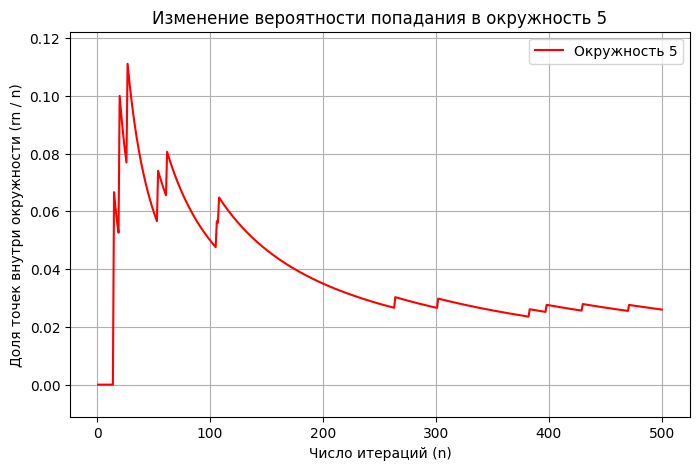

In [ ]:
figsize = (8, 5)

for j in range(num_rad):
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(aw[j][:, 0], aw[j][:, 1], color=colors[j], label=f'Окружность {j+1}')

    y_min, y_max = np.min(aw[j][:, 1]), np.max(aw[j][:, 1])
    ax.set_ylim(y_min - 0.1*(y_max - y_min), y_max + 0.1*(y_max - y_min))

    ax.set_xlabel('Число итераций (n)')
    ax.set_ylabel('Доля точек внутри окружности (rn / n)')
    ax.set_title(f'Изменение вероятности попадания в окружность {j+1}')
    ax.legend()
    ax.grid(True)

    plt.show()


##Построим график к $ε(n) =  | \tilde{p}(n) - {p} |$ для анализа изменения ошибки оценки геометрической вероятности
Нетрудно заметить, что с увеличением $n$, $ε(n)$ приближается к нулю.
Другими словами $\lim\limits_{x \to ∞}ε(n) = 0 $

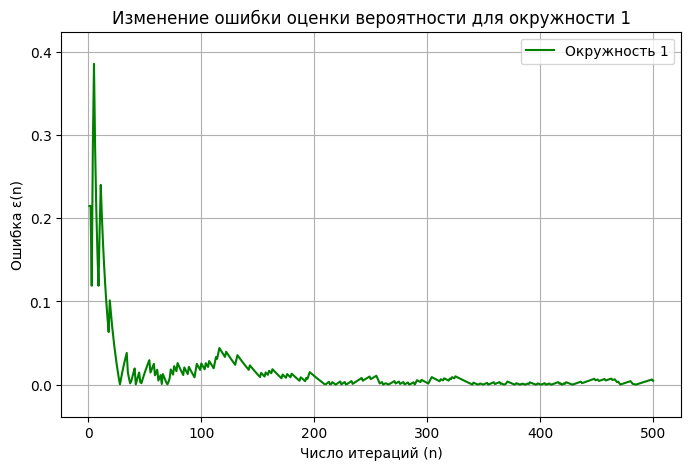

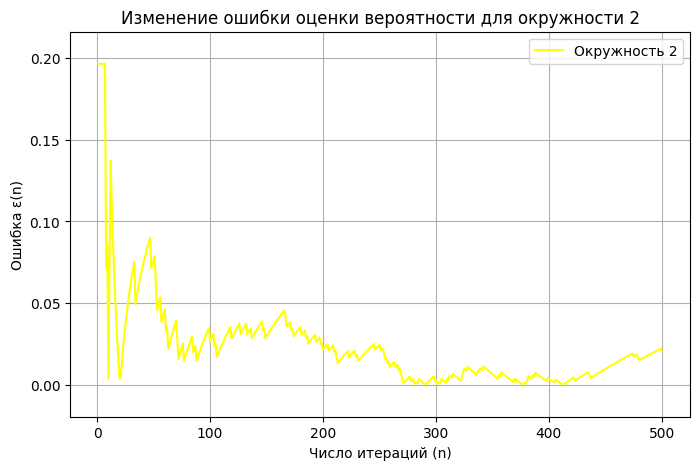

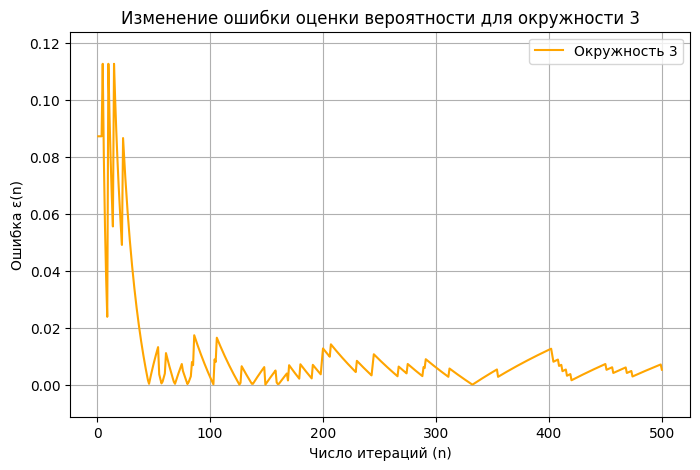

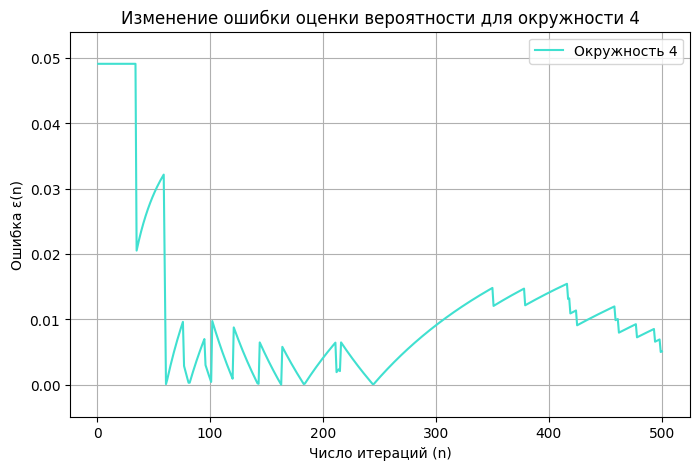

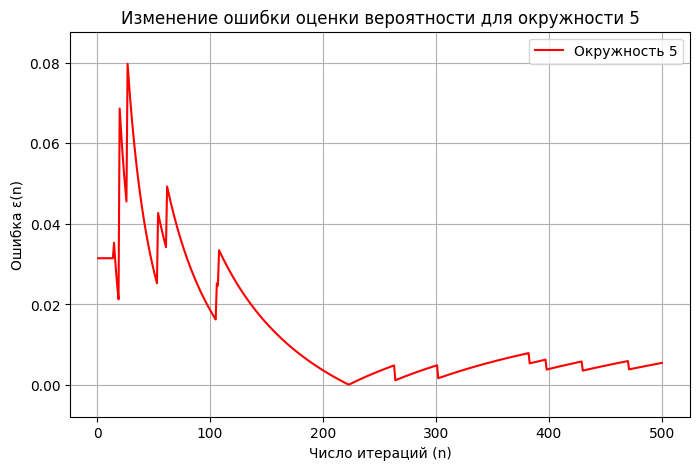

In [ ]:
errors = [np.abs(aw[j][:, 1] - true_geometric_probability[j]) for j in range(num_rad)]

figsize = (8, 5)

for j in range(num_rad):
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(aw[j][:, 0], errors[j], color=colors[j], label=f'Окружность {j+1}')

    y_min, y_max = np.min(errors[j]), np.max(errors[j])
    ax.set_ylim(y_min - 0.1*(y_max - y_min), y_max + 0.1*(y_max - y_min))
    ax.set_xlabel('Число итераций (n)')
    ax.set_ylabel('Ошибка ε(n)')
    ax.set_title(f'Изменение ошибки оценки вероятности для окружности {j+1}')
    ax.legend()
    ax.grid(True)

    plt.show()

##Для каждого радиуса вычислим необходимое количество случайных точек $N$, необходимых для достижения точности $ε_i$. Построим график зависимости $N(ε)$
На этом этапе мы просто найдем минимальное $N$ для каждой точности, которую мы укажем. Данная точность показывает, насколько мы хотим точное значение нашей ошибки оценки геометрической вероятности

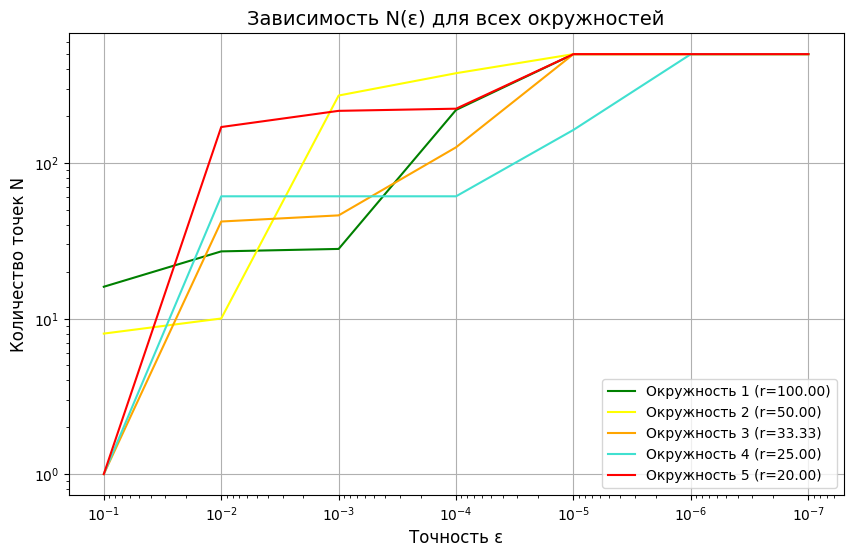

In [ ]:
epsilon_values = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]

N_values = []

for j in range(num_rad):
    N_epsilon = []
    for epsilon in epsilon_values:
        mask = errors[j] <= epsilon
        if np.any(mask):
            N_min = aw[j][mask, 0][0]
        else:
            N_min = num_point
        N_epsilon.append(N_min)
    N_values.append(N_epsilon)

fig, ax = plt.subplots(figsize=(10, 6))

for j in range(num_rad):
    ax.plot(epsilon_values, N_values[j], color=colors[j], label=f'Окружность {j+1} (r={rad[j]:.2f})')

ax.set_xlabel('Точность ε', fontsize=12)
ax.set_ylabel('Количество точек N', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Зависимость N(ε) для всех окружностей', fontsize=14)

ax.legend(fontsize=10, loc='lower right')

ax.grid(True)

ax.invert_xaxis()

plt.show()